# **Project Title**
## 📈 Stock Price Prediction (Next Day Close)


### **🎯 Objective**
Predict the next day closing price of a stock using historical market data.

### **📊 Models Used**
- Linear Regression
- Random Forest Regressor

### **📦 Features**
Open, High, Low, Volume

### **🧠 Target**
Next Day Close Price

 **1. Install Libraries**

In [1]:
!pip install yfinance pandas numpy matplotlib scikit-learn

 **2. Import Libraries**

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

**3. Load Dataset**

In [8]:
stock_symbol = "AAPL"   # You can change to TSLA, MSFT, etc.

df = yf.download(stock_symbol, start="2025-06-01", end="2026-06-02")

df.head()

/tmp/ipykernel_11687/1988184888.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_symbol, start="2025-06-01", end="2026-06-02")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-06-02,200.902954,201.331263,199.329196,199.488567,35423300
2025-06-03,202.466782,202.964806,200.165912,200.554370,46381600
2025-06-04,202.018555,205.425039,201.301399,202.108195,43604000
2025-06-05,199.837204,203.940919,199.359090,202.695858,55126100
2025-06-06,203.114197,204.887162,201.251591,202.197834,46607700


**4. Data Prepration**

In [9]:
# Keep important features
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Create target (Next day's Close price)
df['Target'] = df['Close'].shift(-1)

# Remove last row (NaN target)
df.dropna(inplace=True)

df.head()

Price,Open,High,Low,Close,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2025-06-02,199.488567,201.331263,199.329196,200.902954,35423300,202.466782
2025-06-03,200.554370,202.964806,200.165912,202.466782,46381600,202.018555
2025-06-04,202.108195,205.425039,201.301399,202.018555,43604000,199.837204
2025-06-05,202.695858,203.940919,199.359090,199.837204,55126100,203.114197
2025-06-06,202.197834,204.887162,201.251591,203.114197,46607700,200.653946


**5. Define Features & Target**

In [10]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

**6. Time-Series Train / Test Split**

In [11]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

**7. Train Models**

In [12]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Random Forest (Improved Model)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**8. Predictions**

In [13]:
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

**9. Model Evaluation**

In [15]:
lr_mse = mean_squared_error(y_test, lr_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

print("Linear Regression MSE:", lr_mse)
print("Random Forest MSE:", rf_mse)

Linear Regression MSE: 19.884563753344725
Random Forest MSE: 175.22732333397528


**10. Visualization (Actual vs Predictions)**

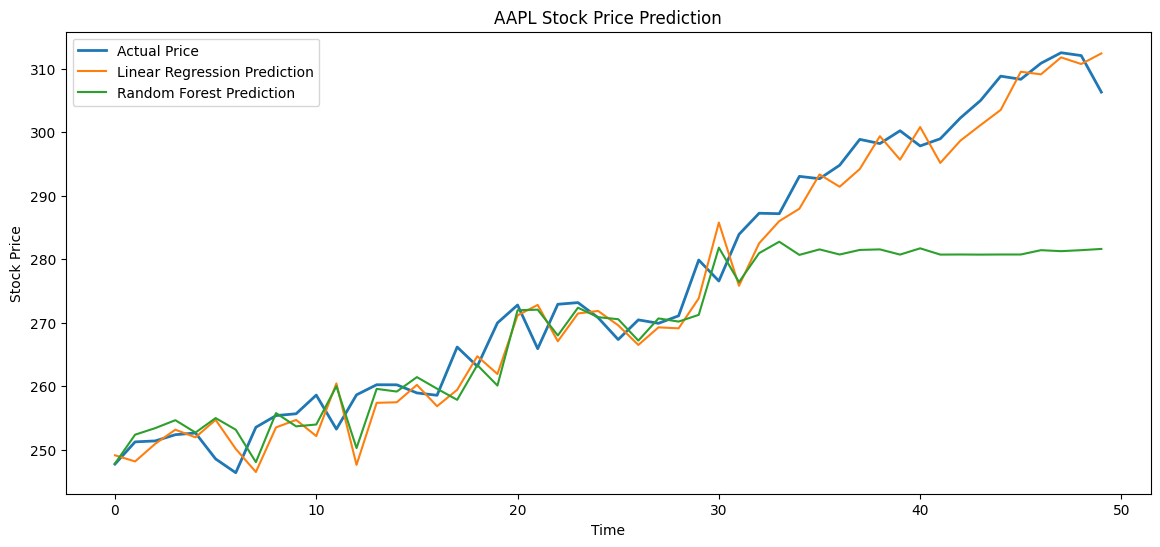

In [16]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual Price", linewidth=2)
plt.plot(lr_pred, label="Linear Regression Prediction")
plt.plot(rf_pred, label="Random Forest Prediction")

plt.title(f"{stock_symbol} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

**11. Predict Next Day Price**

In [17]:
latest_data = X.iloc[-1].values.reshape(1, -1)

lr_next = lr_model.predict(latest_data)
rf_next = rf_model.predict(latest_data)

print("Linear Regression Next Day Price:", lr_next[0])
print("Random Forest Next Day Price:", rf_next[0])

Linear Regression Next Day Price: 312.3979494205869
Random Forest Next Day Price: 281.6269888305664


# **Final Model Comparison (Markdown)**

## 📊 Model Comparison

- Linear Regression → Simple baseline model
- Random Forest → More accurate and powerful

👉 In most cases, Random Forest performs better for this dataset.